# 04 — Latent risk factors (PCA and clustering)

The models above predict returns. This notebook asks a different question: **what hidden factors drive how these 52 stocks move together?**

**PCA** on daily returns finds the few directions that explain most co-movement. We then **cluster** stocks by their factor loadings and check whether the clusters recover the real sectors, without the algorithm ever being told the sectors.

All logic lives in `src/factors.py`.

In [8]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import UNIVERSE, REPORTS_DIR, MARKET
from src.data import load_prices
from src.factors import pca_factors, cluster_stocks

close, volume = load_prices()
pca, loadings, factor_rets = pca_factors(close)

## 1. How much does each factor explain?

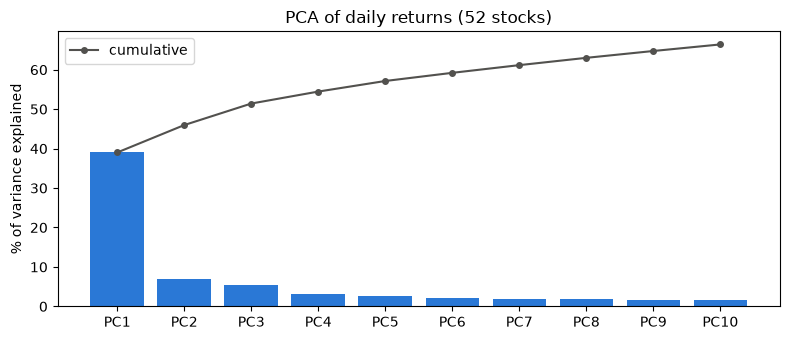

,% variance
PC1,39.0
PC2,7.0
PC3,5.5
PC4,3.0
PC5,2.7
PC6,2.1
PC7,2.0
PC8,1.8
PC9,1.7
PC10,1.7


In [9]:
evr = pd.Series(pca.explained_variance_ratio_, index=loadings.columns)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(evr.index, evr.values * 100, color="#2a78d6")
ax.plot(evr.index, evr.cumsum().values * 100, color="#52514e", marker="o", ms=4, label="cumulative")
ax.set_ylabel("% of variance explained"); ax.set_title("PCA of daily returns (52 stocks)"); ax.legend()
plt.tight_layout(); plt.savefig(REPORTS_DIR / "pca_variance.png", dpi=150); plt.show()
(evr * 100).round(1).to_frame("% variance")

## 2. PC1 is the market
If PC1 is the market factor, its daily returns should be almost perfectly correlated with SPY.

In [10]:
spy = close[MARKET].pct_change().reindex(factor_rets.index)
pc1_corr = factor_rets["PC1"].corr(spy)
print(f"Correlation of PC1 with SPY daily returns: {pc1_corr:.3f}")

Correlation of PC1 with SPY daily returns: 0.952


## 3. What do PC2 and PC3 represent?
Stocks with the most positive and most negative loadings, with their sector.

In [11]:
for pc in ["PC2", "PC3"]:
    s = loadings[pc].sort_values()
    show = pd.concat([s.head(5), s.tail(5)]).to_frame("loading")
    show["sector"] = show.index.map(UNIVERSE)
    print(pc); display(show.round(3))

PC2


,loading,sector
GS,-0.184,Financials
C,-0.184,Financials
MS,-0.173,Financials
BAC,-0.170,Financials
SLB,-0.163,Energy
KO,0.228,Consumer
JNJ,0.235,Health
DUK,0.266,Utilities/Telecom
PEP,0.270,Consumer
PG,0.271,Consumer


PC3


,loading,sector
XOM,-0.238,Energy
CVX,-0.215,Energy
COP,-0.214,Energy
SLB,-0.197,Energy
T,-0.150,Utilities/Telecom
GOOGL,0.251,Tech
ADBE,0.266,Tech
MSFT,0.273,Tech
NVDA,0.291,Tech
AMZN,0.297,Tech


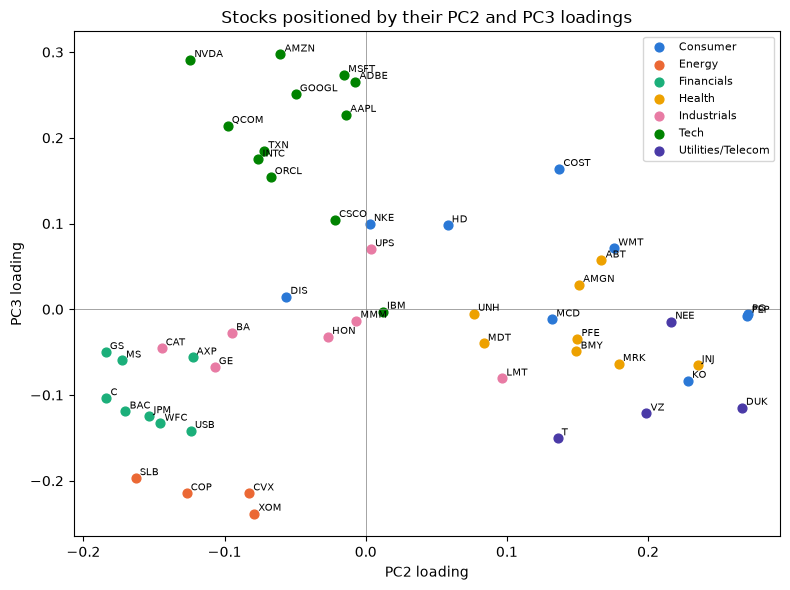

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sectors = sorted(set(UNIVERSE.values()))
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
for sec, c in zip(sectors, colors):
    idx = [t for t in loadings.index if UNIVERSE[t] == sec]
    ax.scatter(loadings.loc[idx, "PC2"], loadings.loc[idx, "PC3"], color=c, label=sec, s=40)
    for t in idx:
        ax.annotate(t, (loadings.loc[t, "PC2"], loadings.loc[t, "PC3"]), fontsize=7, xytext=(3, 2), textcoords="offset points")
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("PC2 loading"); ax.set_ylabel("PC3 loading"); ax.legend(fontsize=8)
ax.set_title("Stocks positioned by their PC2 and PC3 loadings")
plt.tight_layout(); plt.savefig(REPORTS_DIR / "pca_loadings.png", dpi=150); plt.show()

## 4. Clustering: do the factors rediscover sectors?
K-means with 7 clusters on each stock's PC2–PC6 loadings. The **adjusted Rand index** measures agreement with true sectors: 1 = perfect, 0 = no better than random.

In [13]:
labels, ari = cluster_stocks(loadings, UNIVERSE)
print(f"Adjusted Rand index vs true sectors: {ari:.2f}")
pd.crosstab(labels.index.map(UNIVERSE), labels, rownames=["sector"], colnames=["cluster"])

Adjusted Rand index vs true sectors: 0.52


cluster,0,1,2,3,4,5,6
sector,,,,,,,
Consumer,0,0,0,0,4,0,5
Energy,0,0,0,0,0,4,0
Financials,0,0,0,8,0,0,0
Health,0,0,7,0,0,0,1
Industrials,0,3,0,1,0,0,3
Tech,6,5,0,0,0,0,1
Utilities/Telecom,0,0,0,0,4,0,0


## 5. Key numbers (text summary)

In [14]:
print("Variance explained (%):")
print((evr * 100).round(1).to_string())
print(f"\nPC1 correlation with SPY: {pc1_corr:.3f}")
print(f"Adjusted Rand index (clusters vs sectors): {ari:.2f}")
print("\nSector x cluster table:")
print(pd.crosstab(labels.index.map(UNIVERSE), labels).to_string())
for pc in ["PC2", "PC3"]:
    s = loadings[pc].sort_values()
    print(f"\n{pc} most negative:", [(t, UNIVERSE[t]) for t in s.index[:4]])
    print(f"{pc} most positive:", [(t, UNIVERSE[t]) for t in s.index[-4:]])

Variance explained (%):
PC1     39.0
PC2      7.0
PC3      5.5
PC4      3.0
PC5      2.7
PC6      2.1
PC7      2.0
PC8      1.8
PC9      1.7
PC10     1.7

PC1 correlation with SPY: 0.952
Adjusted Rand index (clusters vs sectors): 0.52

Sector x cluster table:
cluster            0  1  2  3  4  5  6
row_0                                 
Consumer           0  0  0  0  4  0  5
Energy             0  0  0  0  0  4  0
Financials         0  0  0  8  0  0  0
Health             0  0  7  0  0  0  1
Industrials        0  3  0  1  0  0  3
Tech               6  5  0  0  0  0  1
Utilities/Telecom  0  0  0  0  4  0  0

PC2 most negative: [('GS', 'Financials'), ('C', 'Financials'), ('MS', 'Financials'), ('BAC', 'Financials')]
PC2 most positive: [('JNJ', 'Health'), ('DUK', 'Utilities/Telecom'), ('PEP', 'Consumer'), ('PG', 'Consumer')]

PC3 most negative: [('XOM', 'Energy'), ('CVX', 'Energy'), ('COP', 'Energy'), ('SLB', 'Energy')]
PC3 most positive: [('ADBE', 'Tech'), ('MSFT', 'Tech'), ('NVDA', 'Tech'),

## Takeaways

- **PC1 is the market factor:** it explains 39% of daily return variance and has a 0.95 correlation with SPY. The first 3 components explain 51.5%, the first 10 about 66%.
- **PC2 (7%) is defensive vs cyclical:** highest loadings on J&J, Duke Energy, PepsiCo and P&G.
- **PC3 (5.5%) is energy vs tech:** Exxon, Chevron, ConocoPhillips and Schlumberger on one side; Adobe, Microsoft, Nvidia and Amazon on the other.
- **Clustering on PC2–PC6 loadings recovers sectors without being told them** (adjusted Rand index 0.52): Financials 8/8, Energy 4/4, Health 7/8. The "errors" are economically sensible: utilities/telecom grouped with consumer staples (defensives), and tech split into two groups.